# Unsupervised Learning Overview

            ## 1. Learning objectives

            - Distinguish supervised and unsupervised learning
- Explain distance, centroids, density, and representations
- Evaluate a grouping without using hidden labels during fitting

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Find useful patterns, groups, compact representations, or unusual observations using only feature columns.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            Imagine sorting an unlabeled box of objects. Shape, size, and color suggest possible organizations, but no answer key says which organization is best.

## 6. Mathematical foundation

            $$d(\mathbf{x},\mathbf{c})=\sqrt{\sum_{j=1}^{p}(x_j-c_j)^2}.$$

            **Every symbol:**

            - $\mathbf{x}$ is one observation.
- $\mathbf{c}$ is a reference point such as a centroid.
- $p$ is the number of features.
- $j$ indexes a feature.
- $d$ is Euclidean distance.

            **Why the equation is needed:** Distance turns similarity into a quantity the algorithm can compare.

            **Small numerical example:** For $\mathbf{x}=(1,2)$ and $\mathbf{c}=(4,6)$, $d=\sqrt{3^2+4^2}=5$.

            **Connection to Python:** np.linalg.norm(x - c) evaluates exactly this distance.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def kmeans_scratch(features, n_clusters, max_iter=100, seed=42):
    generator = np.random.default_rng(seed)
    centroids = features[generator.choice(len(features), n_clusters, replace=False)].copy()
    for _ in range(max_iter):
        distances = np.linalg.norm(features[:, None, :] - centroids[None, :, :], axis=2)
        labels = distances.argmin(axis=1)
        new_centroids = np.vstack([
            features[labels == cluster].mean(axis=0)
            if np.any(labels == cluster) else centroids[cluster]
            for cluster in range(n_clusters)
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    inertia = float(np.sum((features - centroids[labels]) ** 2))
    return labels, centroids, inertia

tiny = np.array([[0., 0.], [0., 1.], [5., 5.], [5., 6.]])
tiny_labels, tiny_centroids, tiny_inertia = kmeans_scratch(tiny, 2)
print("Tiny centroids:", tiny_centroids.round(2).tolist(), "inertia:", round(tiny_inertia, 2))

Tiny centroids: [[0.0, 0.5], [5.0, 5.5]] inertia: 1.0


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Shape: (300, 2)
Scratch/library agreement (ARI): 0.443
Library silhouette: 0.841


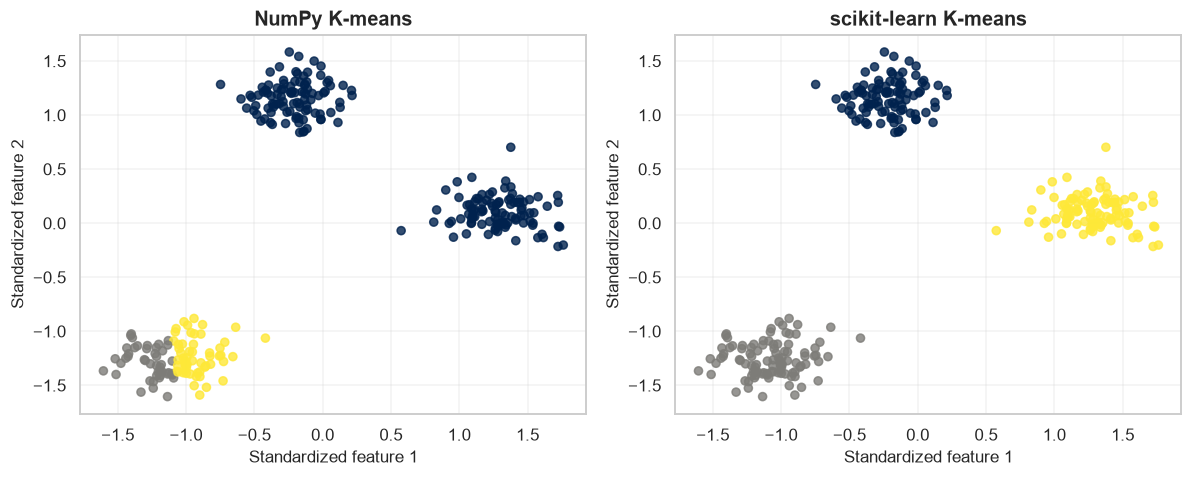

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X, hidden_labels = make_blobs(n_samples=300, centers=3, cluster_std=1.05, random_state=RANDOM_SEED)
X_scaled = StandardScaler().fit_transform(X)
scratch_labels, scratch_centroids, scratch_inertia = kmeans_scratch(X_scaled, 3)
library_model = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
print("Shape:", X_scaled.shape)
print("Scratch/library agreement (ARI):", round(adjusted_rand_score(scratch_labels, library_model.labels_), 3))
print("Library silhouette:", round(silhouette_score(X_scaled, library_model.labels_), 3))

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, labels, title in zip(
    axes,
    [scratch_labels, library_model.labels_],
    ["NumPy K-means", "scikit-learn K-means"],
):
    axis.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="cividis", s=28, alpha=.8)
    axis.set(title=title, xlabel="Standardized feature 1", ylabel="Standardized feature 2")
figure.tight_layout()
plt.show()

**How to interpret the result:** Both implementations recover the same broad groups. Hidden synthetic labels are used only for a post-hoc teaching check, never to fit K-means.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

We vary the main complexity control and compare a quantitative score with the visual result.

,k,inertia,silhouette
0,2,189.173,0.683
1,3,20.046,0.841
2,4,16.965,0.674
3,5,13.960,0.519
4,6,11.741,0.358


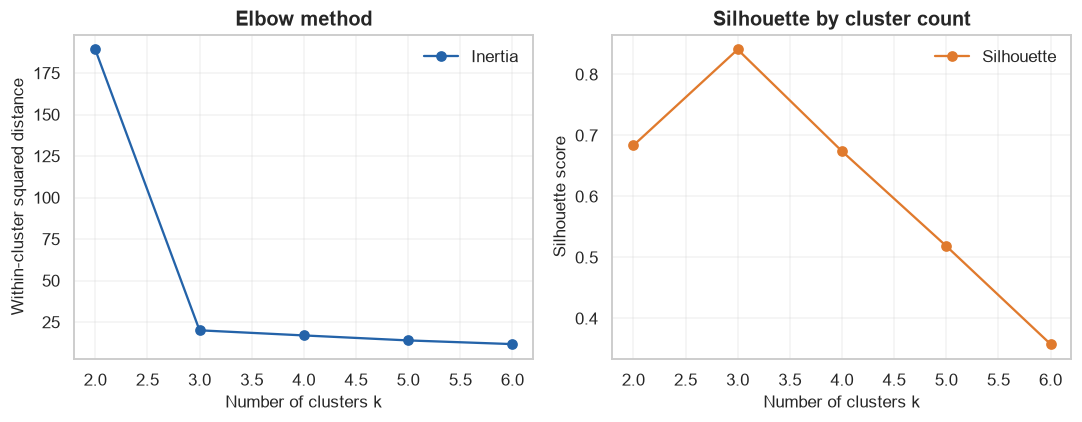

In [4]:
rows = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
    rows.append({"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X_scaled, model.labels_)})
scores = pd.DataFrame(rows)
display(scores.round(3))
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(scores["k"], scores["inertia"], marker="o", label="Inertia", color=COURSE_COLORS["blue"])
axes[0].set(title="Elbow method", xlabel="Number of clusters k", ylabel="Within-cluster squared distance")
axes[0].legend()
axes[1].plot(scores["k"], scores["silhouette"], marker="o", label="Silhouette", color=COURSE_COLORS["orange"])
axes[1].set(title="Silhouette by cluster count", xlabel="Number of clusters k", ylabel="Silhouette score")
axes[1].legend()
figure.tight_layout()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)
- [scikit-learn decomposition guide](https://scikit-learn.org/stable/modules/decomposition.html)